# Класифікація котів та собак

In [13]:
import os
import random
import shutil
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from keras.utils import image_dataset_from_directory
from keras.applications import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input

In [14]:
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DATA_DIR = PROJECT_DIR / "data" / "raw" / "kagglecatsanddogs" / "PetImages"
CAT_DIR = RAW_DATA_DIR / "Cat"
DOG_DIR = RAW_DATA_DIR / "Dog"

print(PROJECT_DIR)
print(CAT_DIR.exists())
print(DOG_DIR.exists())

c:\Users\hyper\OneDrive\Рабочий стол\cats-dogs-classification
True
True


In [15]:
cat_files = list(CAT_DIR.glob("*.jpg"))
dog_files = list(DOG_DIR.glob("*.jpg"))

df = pd.DataFrame({
    "filepath": [str(path) for path in cat_files + dog_files],
    "label": ["cat"] * len(cat_files) + ["dog"] * len(dog_files)
})

df.head()

,filepath,label
0,c:\Users\hyper\OneDrive\Рабочий стол\cats-dogs...,cat
1,c:\Users\hyper\OneDrive\Рабочий стол\cats-dogs...,cat
2,c:\Users\hyper\OneDrive\Рабочий стол\cats-dogs...,cat
3,c:\Users\hyper\OneDrive\Рабочий стол\cats-dogs...,cat
4,c:\Users\hyper\OneDrive\Рабочий стол\cats-dogs...,cat


In [16]:
print("Кількість зображень:", len(df))
print(df["label"].value_counts())

Кількість зображень: 25000
label
cat    12500
dog    12500
Name: count, dtype: int64


## Опис датасету

Датасет складається із зображень котів та собак, розподілених у дві папки відповідно до класів. Клас `cat` відповідає зображенням котів, а клас `dog` — зображенням собак.

На початковому етапі було сформовано таблицю з повними шляхами до файлів та відповідними мітками класів. Це дозволяє зручно аналізувати кількість зображень, баланс класів та виконувати подальшу підготовку даних.

In [17]:
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DATA_DIR = PROJECT_DIR / "data" / "raw" / "kagglecatsanddogs" / "PetImages"
CAT_DIR = RAW_DATA_DIR / "Cat"
DOG_DIR = RAW_DATA_DIR / "Dog"

print(PROJECT_DIR)
print(RAW_DATA_DIR)
print(CAT_DIR.exists())
print(DOG_DIR.exists())

c:\Users\hyper\OneDrive\Рабочий стол\cats-dogs-classification
c:\Users\hyper\OneDrive\Рабочий стол\cats-dogs-classification\data\raw\kagglecatsanddogs\PetImages
True
True


In [18]:
print("Notebook працює")
print(tf.__version__)

Notebook працює
2.21.0


In [19]:
cat_files = list(CAT_DIR.glob("*.jpg"))
dog_files = list(DOG_DIR.glob("*.jpg"))

df = pd.DataFrame({
    "filepath": [str(path) for path in cat_files + dog_files],
    "label": ["cat"] * len(cat_files) + ["dog"] * len(dog_files)
})

df.head()

,filepath,label
0,c:\Users\hyper\OneDrive\Рабочий стол\cats-dogs...,cat
1,c:\Users\hyper\OneDrive\Рабочий стол\cats-dogs...,cat
2,c:\Users\hyper\OneDrive\Рабочий стол\cats-dogs...,cat
3,c:\Users\hyper\OneDrive\Рабочий стол\cats-dogs...,cat
4,c:\Users\hyper\OneDrive\Рабочий стол\cats-dogs...,cat


In [20]:
print("Кількість зображень:", len(df))
print(df["label"].value_counts())

Кількість зображень: 25000
label
cat    12500
dog    12500
Name: count, dtype: int64


## Очищення даних

Перед навчанням моделі потрібно перевірити, чи всі зображення коректно відкриваються. У датасеті можуть бути пошкоджені або некоректні файли, які можуть викликати помилки під час навчання нейронної мережі.

Для очищення було виконано перевірку кожного зображення за допомогою бібліотеки PIL. Некоректні файли видаляються з таблиці даних і не використовуються під час навчання.

In [21]:
valid_files = []
invalid_files = []

for filepath, label in zip(df["filepath"], df["label"]):
    try:
        with Image.open(filepath) as img:
            img.verify()
        valid_files.append((filepath, label))
    except Exception:
        invalid_files.append(filepath)

clean_df = pd.DataFrame(valid_files, columns=["filepath", "label"])

print("Всього файлів:", len(df))
print("Коректних файлів:", len(clean_df))
print("Пошкоджених файлів:", len(invalid_files))

c:\Users\hyper\OneDrive\Рабочий стол\cats-dogs-classification\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Всього файлів: 25000
Коректних файлів: 24998
Пошкоджених файлів: 2


In [22]:
clean_df["label"].value_counts()

label
cat    12499
dog    12499
Name: count, dtype: int64

## Експлораторний аналіз даних

На цьому етапі виконується базовий аналіз датасету: перевіряється баланс класів, візуалізуються приклади зображень та аналізуються розміри фотографій. Це дозволяє краще зрозуміти структуру даних перед навчанням моделі.

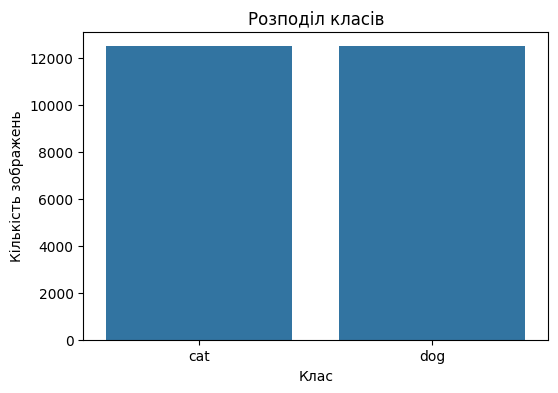

label
cat    12499
dog    12499
Name: count, dtype: int64


In [23]:
plt.figure(figsize=(6, 4))
sns.countplot(data=clean_df, x="label")
plt.title("Розподіл класів")
plt.xlabel("Клас")
plt.ylabel("Кількість зображень")
plt.show()

print(clean_df["label"].value_counts())

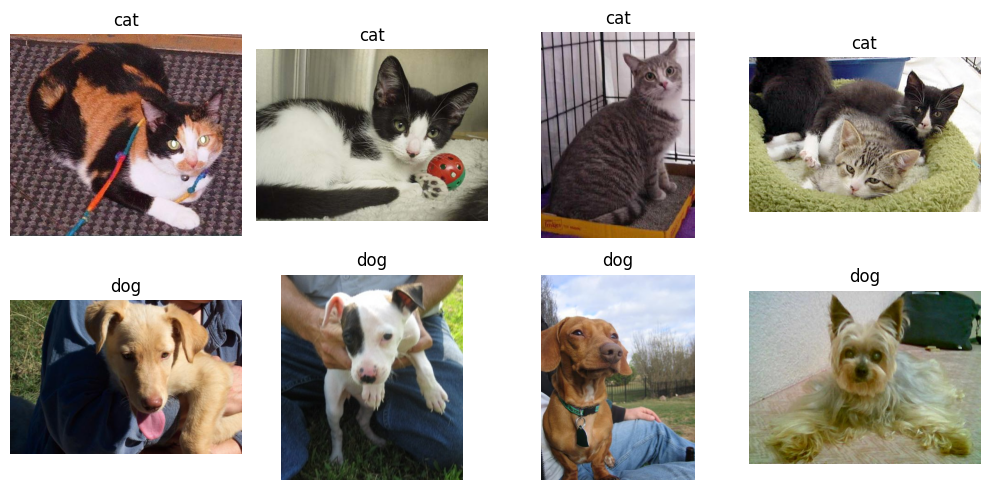

In [24]:
sample_df = clean_df.groupby("label").sample(4, random_state=42)

plt.figure(figsize=(10, 5))

for i, row in enumerate(sample_df.itertuples(), 1):
    img = Image.open(row.filepath)
    plt.subplot(2, 4, i)
    plt.imshow(img)
    plt.title(row.label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
image_sizes = []

for filepath in clean_df["filepath"].sample(1000, random_state=42):
    with Image.open(filepath) as img:
        image_sizes.append(img.size)

sizes_df = pd.DataFrame(image_sizes, columns=["width", "height"])

sizes_df.describe()

,width,height
count,1000.000000,1000.00000
mean,400.840000,361.61100
std,107.074934,101.02345
min,60.000000,37.00000
25%,320.000000,299.00000
50%,425.000000,375.00000
75%,500.000000,443.25000
max,500.000000,500.00000


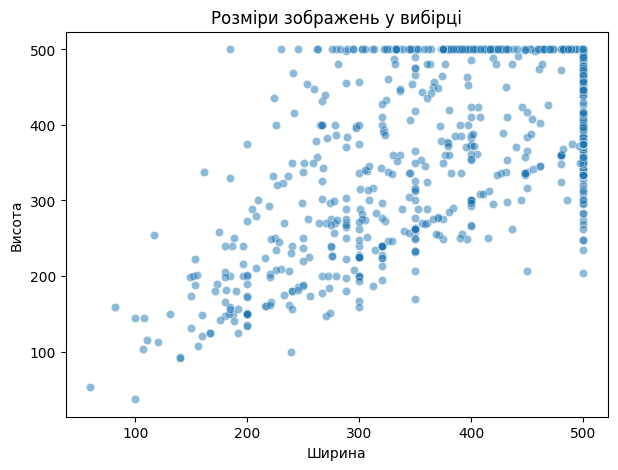

In [26]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=sizes_df, x="width", y="height", alpha=0.5)
plt.title("Розміри зображень у вибірці")
plt.xlabel("Ширина")
plt.ylabel("Висота")
plt.show()

## Підготовка даних для навчання

Після очищення датасету я розділив зображення на три частини train, validation і test. Train використовується для навчання моделі, validation  для перевірки результатів під час навчання, test  для фінальної оцінки вже готової моделі.

Також я розклав зображення по окремих папках для кожного класу, щоб їх можна було зручно завантажити через `image_dataset_from_directory`.

In [27]:
train_df, temp_df = train_test_split(
    clean_df,
    test_size=0.3,
    stratify=clean_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print(train_df["label"].value_counts())
print(val_df["label"].value_counts())
print(test_df["label"].value_counts())

Train: 17498
Validation: 3750
Test: 3750
label
dog    8749
cat    8749
Name: count, dtype: int64
label
dog    1875
cat    1875
Name: count, dtype: int64
label
dog    1875
cat    1875
Name: count, dtype: int64


In [28]:
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
TRAIN_DIR = PROCESSED_DIR / "train"
VAL_DIR = PROCESSED_DIR / "validation"
TEST_DIR = PROCESSED_DIR / "test"

for directory in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for label in ["cat", "dog"]:
        (directory / label).mkdir(parents=True, exist_ok=True)

def copy_images(dataframe, target_dir):
    for row in dataframe.itertuples():
        source_path = Path(row.filepath)
        target_path = target_dir / row.label / source_path.name
        if not target_path.exists():
            shutil.copy2(source_path, target_path)

copy_images(train_df, TRAIN_DIR)
copy_images(val_df, VAL_DIR)
copy_images(test_df, TEST_DIR)

print("Файли скопійовано")

Файли скопійовано


In [29]:
for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(split_dir.name)
    print("cat:", len(list((split_dir / "cat").glob("*.jpg"))))
    print("dog:", len(list((split_dir / "dog").glob("*.jpg"))))

train
cat: 8749
dog: 8749
validation
cat: 1875
dog: 1875
test
cat: 1875
dog: 1875


CNN

CNN модель складається з кількох згорткових шарів, які поступово обробляють зображення і знаходять у них корисні ознаки.
Цю модель я використав як базовий варіант, щоб потім порівняти її результат із моделлю MobileNetV2 на основі transfer learning.

In [30]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32
SEED = 42

train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds = image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_ds = image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print(class_names)

Found 17498 files belonging to 2 classes.
Found 3750 files belonging to 2 classes.
Found 3750 files belonging to 2 classes.
['cat', 'dog']


In [31]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [32]:
cnn_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(160, 160, 3)),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

c:\Users\hyper\OneDrive\Рабочий стол\cats-dogs-classification\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,401,921 (20.61 MB)

 Trainable params: 5,401,921 (20.61 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5


InvalidArgumentError: Graph execution error:

Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
Number of channels inherent in the image must be 1, 3 or 4, was 2
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]] [Op:__inference_multi_step_on_iterator_2265]

In [34]:
valid_rgb_files = []
invalid_rgb_files = []

for filepath, label in zip(clean_df["filepath"], clean_df["label"]):
    try:
        with Image.open(filepath) as img:
            img = img.convert("RGB")
            arr = np.array(img)
            
            if arr.ndim == 3 and arr.shape[2] == 3:
                valid_rgb_files.append((filepath, label))
            else:
                invalid_rgb_files.append(filepath)
    except Exception:
        invalid_rgb_files.append(filepath)

clean_df = pd.DataFrame(valid_rgb_files, columns=["filepath", "label"])

print("Коректних RGB-файлів:", len(clean_df))
print("Некоректних RGB-файлів:", len(invalid_rgb_files))
print(clean_df["label"].value_counts())

c:\Users\hyper\OneDrive\Рабочий стол\cats-dogs-classification\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Коректних RGB-файлів: 24998
Некоректних RGB-файлів: 0
label
cat    12499
dog    12499
Name: count, dtype: int64


In [35]:
if PROCESSED_DIR.exists():
    shutil.rmtree(PROCESSED_DIR)

print("Папку processed очищено")

Папку processed очищено


In [36]:
train_df, temp_df = train_test_split(
    clean_df,
    test_size=0.3,
    stratify=clean_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print(train_df["label"].value_counts())
print(val_df["label"].value_counts())
print(test_df["label"].value_counts())

Train: 17498
Validation: 3750
Test: 3750
label
dog    8749
cat    8749
Name: count, dtype: int64
label
dog    1875
cat    1875
Name: count, dtype: int64
label
dog    1875
cat    1875
Name: count, dtype: int64


In [37]:
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
TRAIN_DIR = PROCESSED_DIR / "train"
VAL_DIR = PROCESSED_DIR / "validation"
TEST_DIR = PROCESSED_DIR / "test"

for directory in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for label in ["cat", "dog"]:
        (directory / label).mkdir(parents=True, exist_ok=True)

def copy_images(dataframe, target_dir):
    for row in dataframe.itertuples():
        source_path = Path(row.filepath)
        target_path = target_dir / row.label / source_path.name
        if not target_path.exists():
            shutil.copy2(source_path, target_path)

copy_images(train_df, TRAIN_DIR)
copy_images(val_df, VAL_DIR)
copy_images(test_df, TEST_DIR)

print("Файли скопійовано")

Файли скопійовано


In [38]:
for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(split_dir.name)
    print("cat:", len(list((split_dir / "cat").glob("*.jpg"))))
    print("dog:", len(list((split_dir / "dog").glob("*.jpg"))))

train
cat: 8749
dog: 8749
validation
cat: 1875
dog: 1875
test
cat: 1875
dog: 1875


In [39]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32
SEED = 42

train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds = image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_ds = image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print(class_names)

Found 17498 files belonging to 2 classes.
Found 3750 files belonging to 2 classes.
Found 3750 files belonging to 2 classes.
['cat', 'dog']


In [40]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [41]:
cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5


InvalidArgumentError: Graph execution error:

Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
Number of channels inherent in the image must be 1, 3 or 4, was 2
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]] [Op:__inference_multi_step_on_iterator_2265]

In [42]:
if PROCESSED_DIR.exists():
    shutil.rmtree(PROCESSED_DIR)

print("Папку processed очищено")

Папку processed очищено


In [43]:
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
TRAIN_DIR = PROCESSED_DIR / "train"
VAL_DIR = PROCESSED_DIR / "validation"
TEST_DIR = PROCESSED_DIR / "test"

for directory in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for label in ["cat", "dog"]:
        (directory / label).mkdir(parents=True, exist_ok=True)

def save_rgb_images(dataframe, target_dir):
    skipped_files = []

    for row in dataframe.itertuples():
        source_path = Path(row.filepath)
        target_path = target_dir / row.label / source_path.name

        try:
            with Image.open(source_path) as img:
                img = img.convert("RGB")
                img.save(target_path, format="JPEG")
        except Exception:
            skipped_files.append(str(source_path))

    return skipped_files

skipped_train = save_rgb_images(train_df, TRAIN_DIR)
skipped_val = save_rgb_images(val_df, VAL_DIR)
skipped_test = save_rgb_images(test_df, TEST_DIR)

skipped_files = skipped_train + skipped_val + skipped_test

print("Файли підготовлено")
print("Пропущено файлів:", len(skipped_files))

c:\Users\hyper\OneDrive\Рабочий стол\cats-dogs-classification\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Файли підготовлено
Пропущено файлів: 0


In [44]:
for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(split_dir.name)
    print("cat:", len(list((split_dir / "cat").glob("*.jpg"))))
    print("dog:", len(list((split_dir / "dog").glob("*.jpg"))))

train
cat: 8749
dog: 8749
validation
cat: 1875
dog: 1875
test
cat: 1875
dog: 1875


In [45]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32
SEED = 42

train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds = image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_ds = image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print(class_names)

Found 17498 files belonging to 2 classes.
Found 3750 files belonging to 2 classes.
Found 3750 files belonging to 2 classes.
['cat', 'dog']


In [46]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [47]:
cnn_model = models.Sequential([
    layers.Input(shape=(160, 160, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,401,921 (20.61 MB)

 Trainable params: 5,401,921 (20.61 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 92s 161ms/step - accuracy: 0.6370 - loss: 0.6309 - val_accuracy: 0.7272 - val_loss: 0.5501
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 90s 159ms/step - accuracy: 0.7509 - loss: 0.5089 - val_accuracy: 0.7797 - val_loss: 0.4876
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 87s 155ms/step - accuracy: 0.8014 - loss: 0.4332 - val_accuracy: 0.7976 - val_loss: 0.4455
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 84s 150ms/step - accuracy: 0.8306 - loss: 0.3765 - val_accuracy: 0.8224 - val_loss: 0.4047
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 85s 152ms/step - accuracy: 0.8632 - loss: 0.3180 - val_accuracy: 0.8317 - val_loss: 0.4020


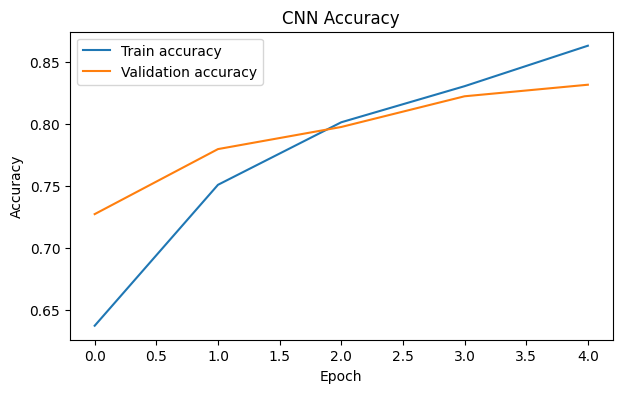

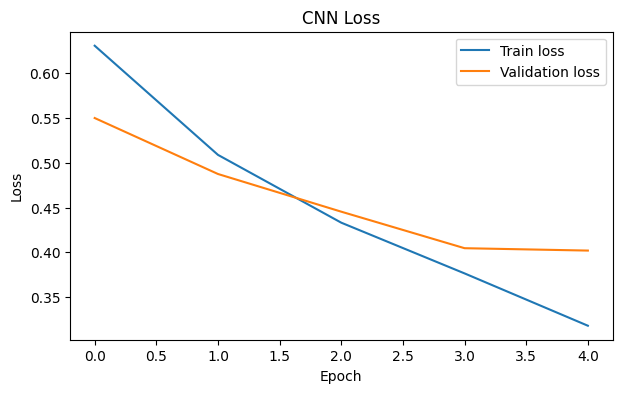

In [49]:
plt.figure(figsize=(7, 4))
plt.plot(cnn_history.history["accuracy"], label="Train accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation accuracy")
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(cnn_history.history["loss"], label="Train loss")
plt.plot(cnn_history.history["val_loss"], label="Validation loss")
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [50]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(test_ds)

print("CNN Test Loss:", cnn_test_loss)
print("CNN Test Accuracy:", cnn_test_accuracy)

118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.8309 - loss: 0.3918
CNN Test Loss: 0.39175179600715637
CNN Test Accuracy: 0.8309333324432373


In [51]:
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = cnn_model.predict(images, verbose=0)
    y_pred_probs.extend(preds.flatten())
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = (y_pred_probs >= 0.5).astype(int)

In [52]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

         cat       0.82      0.85      0.83      1875
         dog       0.84      0.81      0.83      1875

    accuracy                           0.83      3750
   macro avg       0.83      0.83      0.83      3750
weighted avg       0.83      0.83      0.83      3750



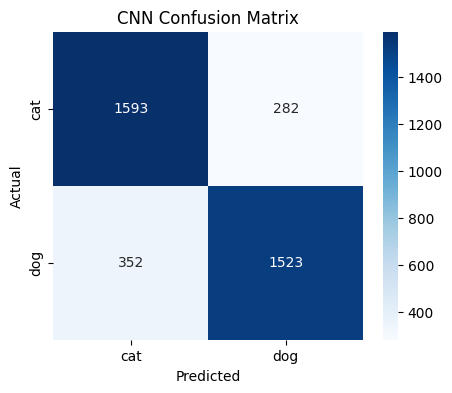

In [53]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [54]:
cnn_metrics = {
    "model": "Simple CNN",
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred),
    "recall": recall_score(y_true, y_pred),
    "f1_score": f1_score(y_true, y_pred)
}

cnn_metrics

{'model': 'Simple CNN',
 'accuracy': 0.8309333333333333,
 'precision': 0.8437673130193906,
 'recall': 0.8122666666666667,
 'f1_score': 0.8277173913043478}

## Побудова другої моделі: Transfer Learning MobileNetV2

Після простої CNN я використав ще один підхід transfer learning. Для цього була взята модель MobileNetV2 яка вже попередньо навчалась на великій кількості зображень.

Основна ідея полягає в тому, що така модель вже вміє знаходити на фото важливі ознаки: форми, контури. Тому її можна не навчати повністю з нуля, а використати як основу для задачі класифікації котів і собак.

У цій моделі базові шари MobileNetV2 були заморожені, а зверху додано власний класифікатор для двох класів: `cat` і `dog`. Це дозволило отримати кращий результат порівняно з простою CNN.

In [55]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

train_tl_ds = image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_tl_ds = image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_tl_ds = image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_tl_ds.class_names
print(class_names)

Found 17498 files belonging to 2 classes.
Found 3750 files belonging to 2 classes.
Found 3750 files belonging to 2 classes.
['cat', 'dog']


In [56]:
AUTOTUNE = tf.data.AUTOTUNE

train_tl_ds = train_tl_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_tl_ds = val_tl_ds.prefetch(buffer_size=AUTOTUNE)
test_tl_ds = test_tl_ds.prefetch(buffer_size=AUTOTUNE)

In [57]:
base_model = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

tl_model = models.Sequential([
    layers.Input(shape=(160, 160, 3)),
    layers.Lambda(preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [58]:
tl_history = tl_model.fit(
    train_tl_ds,
    validation_data=val_tl_ds,
    epochs=5
)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 77s 129ms/step - accuracy: 0.8466 - loss: 0.3509 - val_accuracy: 0.9653 - val_loss: 0.1397
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 72s 128ms/step - accuracy: 0.9647 - loss: 0.1219 - val_accuracy: 0.9757 - val_loss: 0.0892
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 71s 126ms/step - accuracy: 0.9709 - loss: 0.0897 - val_accuracy: 0.9787 - val_loss: 0.0721
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 70s 125ms/step - accuracy: 0.9753 - loss: 0.0746 - val_accuracy: 0.9795 - val_loss: 0.0634
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 72s 127ms/step - accuracy: 0.9785 - loss: 0.0657 - val_accuracy: 0.9811 - val_loss: 0.0582


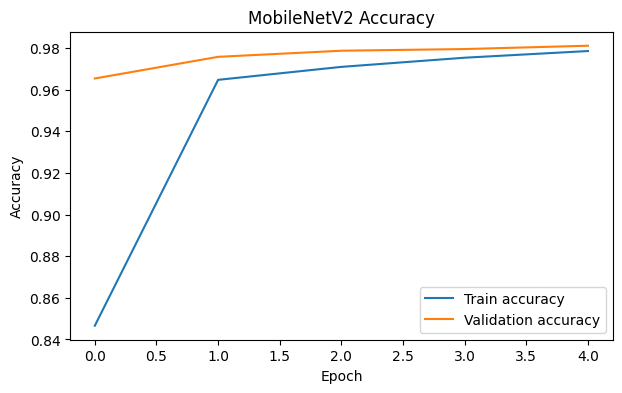

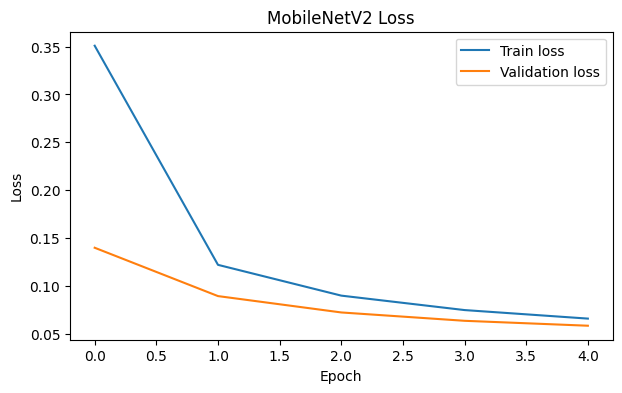

In [59]:
plt.figure(figsize=(7, 4))
plt.plot(tl_history.history["accuracy"], label="Train accuracy")
plt.plot(tl_history.history["val_accuracy"], label="Validation accuracy")
plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(tl_history.history["loss"], label="Train loss")
plt.plot(tl_history.history["val_loss"], label="Validation loss")
plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [60]:
tl_test_loss, tl_test_accuracy = tl_model.evaluate(test_tl_ds)

print("MobileNetV2 Test Loss:", tl_test_loss)
print("MobileNetV2 Test Accuracy:", tl_test_accuracy)

118/118 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - accuracy: 0.9832 - loss: 0.0552
MobileNetV2 Test Loss: 0.05515751987695694
MobileNetV2 Test Accuracy: 0.9832000136375427


In [61]:
tl_y_true = []
tl_y_pred_probs = []

for images, labels in test_tl_ds:
    preds = tl_model.predict(images, verbose=0)
    tl_y_pred_probs.extend(preds.flatten())
    tl_y_true.extend(labels.numpy())

tl_y_true = np.array(tl_y_true)
tl_y_pred_probs = np.array(tl_y_pred_probs)
tl_y_pred = (tl_y_pred_probs >= 0.5).astype(int)

In [62]:
print(classification_report(tl_y_true, tl_y_pred, target_names=class_names))

              precision    recall  f1-score   support

         cat       0.99      0.98      0.98      1875
         dog       0.98      0.99      0.98      1875

    accuracy                           0.98      3750
   macro avg       0.98      0.98      0.98      3750
weighted avg       0.98      0.98      0.98      3750



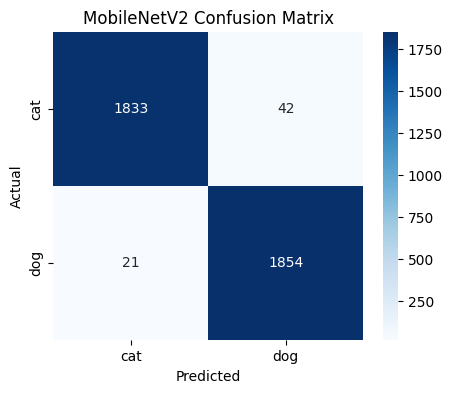

In [63]:
tl_cm = confusion_matrix(tl_y_true, tl_y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    tl_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [64]:
tl_metrics = {
    "model": "MobileNetV2 Transfer Learning",
    "accuracy": accuracy_score(tl_y_true, tl_y_pred),
    "precision": precision_score(tl_y_true, tl_y_pred),
    "recall": recall_score(tl_y_true, tl_y_pred),
    "f1_score": f1_score(tl_y_true, tl_y_pred)
}

tl_metrics

{'model': 'MobileNetV2 Transfer Learning',
 'accuracy': 0.9832,
 'precision': 0.9778481012658228,
 'recall': 0.9888,
 'f1_score': 0.9832935560859188}

In [65]:
results_df = pd.DataFrame([cnn_metrics, tl_metrics])
results_df

,model,accuracy,precision,recall,f1_score
0,Simple CNN,0.830933,0.843767,0.812267,0.827717
1,MobileNetV2 Transfer Learning,0.983200,0.977848,0.988800,0.983294


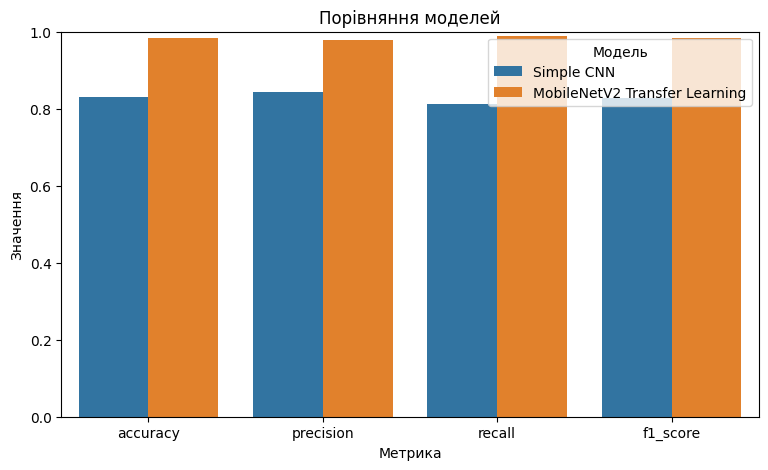

In [66]:
results_melted = results_df.melt(id_vars="model", var_name="metric", value_name="value")

plt.figure(figsize=(9, 5))
sns.barplot(data=results_melted, x="metric", y="value", hue="model")
plt.title("Порівняння моделей")
plt.ylim(0, 1)
plt.xlabel("Метрика")
plt.ylabel("Значення")
plt.legend(title="Модель")
plt.show()

In [67]:
BEST_MODEL_PATH = PROJECT_DIR / "models" / "best_mobilenetv2_model.keras"

tl_model.save(BEST_MODEL_PATH)

print("Модель збережено:", BEST_MODEL_PATH)

Модель збережено: c:\Users\hyper\OneDrive\Рабочий стол\cats-dogs-classification\models\best_mobilenetv2_model.keras


# Висновок
Кращий результат показала модель MobileNetV2. Вона точніше класифікує зображення, бо використовує попередньо навчені шари. Просту CNN я залишив як базову модель для порівняння.